# 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor
import optuna
import joblib


# 2. Data Loading

In [ ]:
files = [
    "C:\\Users\\PC\\Documents\\final_dwh\\final\\survey_results_public_2022.csv",
    "C:\\Users\\PC\\Documents\\final_dwh\\final\\survey_results_public_2023.csv",
    "C:\\Users\\PC\\Documents\\final_dwh\\final\\survey_results_public_2024.csv"
]
dfs = [pd.read_csv(f, low_memory=False) for f in files]
dfs

[       ResponseId                                         MainBranch  \
 0               1                                      None of these   
 1               2                     I am a developer by profession   
 2               3  I am not primarily a developer, but I write co...   
 3               4                     I am a developer by profession   
 4               5                     I am a developer by profession   
 ...           ...                                                ...   
 73263       73264                     I am a developer by profession   
 73264       73265                     I am a developer by profession   
 73265       73266  I am not primarily a developer, but I write co...   
 73266       73267                     I am a developer by profession   
 73267       73268  I used to be a developer by profession, but no...   
 
                                               Employment  \
 0                                                    NaN   


# 3. Initial Exploration

In [ ]:

for i, df in enumerate(dfs, 2022):
    print(f"Dataset {i} shape: {df.shape}")
    print(df.columns.tolist())
    print('-'*80)


Dataset 2022 shape: (73268, 79)
['ResponseId', 'MainBranch', 'Employment', 'RemoteWork', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'LearnCodeCoursesCert', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'Country', 'Currency', 'CompTotal', 'CompFreq', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'OpSysProfessional use', 'OpSysPersonal use', 'VersionControlSystem', 'VCInteraction', 'VCHostingPersonal use', 'VCHostingProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'OfficeStackSyncHaveWorkedWith', 'OfficeStackSyncWantToWorkWith', 'Blockchain', 'NEWSOSites', 'SOVisitF

# 4. Data Preprocessing

In [ ]:
def select_and_rename(df):
    cols = ["Country", "EdLevel", "YearsCodePro", "Employment", "ConvertedCompYearly", "DevType", "Age", "OrgSize", "RemoteWork"]
    df = df[[c for c in cols if c in df.columns]].copy()
    df.rename(columns={
        "ConvertedCompYearly": "Salary",
        "YearsCodePro": "YearsExperience",
        "EdLevel": "EducationLevel",
        "DevType": "DeveloperType",
        "OrgSize": "CompanySize"
    }, inplace=True)
    return df

def clean_employment(x):
    if isinstance(x, str):
        x = x.lower()
        if 'full-time' in x:
            return 'Full-time'
        if 'part-time' in x:
            return 'Part-time'
        if 'self-employed' in x or 'freelance' in x:
            return 'Self-employed'
    return 'Other'

def clean_education(x):
    if isinstance(x, str):
        x = x.lower()
        if 'bachelor' in x:
            return "Bachelor's"
        if 'master' in x:
            return "Master's"
        if 'ph.d' in x or 'doctoral' in x or 'professional' in x:
            return "Postgrad"
    return "Less than Bachelor's"

def clean_dev_type(x):
    if isinstance(x, str):
        x = x.lower()
        if 'full-stack' in x:
            return 'Full-stack'
        if 'back-end' in x:
            return 'Back-end'
        if 'front-end' in x:
            return 'Front-end'
        if 'data scientist' in x or 'machine learning' in x:
            return 'Data Scientist'
        if 'devops' in x:
            return 'DevOps'
    return 'Other'

def clean_company_size(x):
    if isinstance(x, str):
        if '1-9' in x or '1 to 9' in x:
            return 'Small (1-9)'
        if '10-99' in x:
            return 'Medium (10-99)'
        if '100-999' in x:
            return 'Large (100-999)'
        if '1000+' in x or '1,000' in x:
            return 'Enterprise (1000+)'
    return 'Unknown'

def clean_experience(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        if 'less than 1' in x.lower():
            return 0.5
        if 'more than 50' in x.lower():
            return 50
        try:
            return float(x.split()[0])
        except:
            return np.nan
    return float(x)

def preprocess(df, country_cutoff=200):
    df = select_and_rename(df)
    df = df[df['Salary'].notna()]
    df['Employment'] = df['Employment'].apply(clean_employment)
    df = df[df['Employment'] == 'Full-time']
    df['EducationLevel'] = df['EducationLevel'].apply(clean_education)
    if 'DeveloperType' in df.columns:
        df['DeveloperType'] = df['DeveloperType'].apply(clean_dev_type)
    if 'CompanySize' in df.columns:
        df['CompanySize'] = df['CompanySize'].apply(clean_company_size)
    df['YearsExperience'] = df['YearsExperience'].apply(clean_experience)
    df['YearsExperience'] = df['YearsExperience'].fillna(df['YearsExperience'].median())
    country_counts = df['Country'].value_counts()
    df['Country'] = df['Country'].apply(lambda x: x if country_counts.get(x, 0) >= country_cutoff else 'Other')
    df = df[df['Country'] != 'Other']
    salary_q1 = df['Salary'].quantile(0.05)
    salary_q3 = df['Salary'].quantile(0.95)
    df = df[(df['Salary'] > salary_q1) & (df['Salary'] < salary_q3)]
    df['LogSalary'] = np.log1p(df['Salary'])
    df['ExpSquared'] = df['YearsExperience'] ** 2
    return df


In [ ]:
dfs = [preprocess(df) for df in dfs]
data = pd.concat(dfs, ignore_index=True)
data.to_csv("merged_cleaned_salary_data.csv", index=False)
data.head()


,Country,EducationLevel,YearsExperience,Employment,Salary,DeveloperType,Age,CompanySize,RemoteWork,LogSalary,ExpSquared
0,United Kingdom of Great Britain and Northern I...,Master's,5.0,Full-time,40205.0,Front-end,25-34 years old,Unknown,"Hybrid (some remote, some in-person)",10.601772,25.0
1,Israel,Bachelor's,17.0,Full-time,215232.0,Full-stack,35-44 years old,Unknown,Fully remote,12.279476,289.0
2,Netherlands,Master's,6.0,Full-time,49056.0,Back-end,25-34 years old,Unknown,"Hybrid (some remote, some in-person)",10.800738,36.0
3,United Kingdom of Great Britain and Northern I...,Bachelor's,2.0,Full-time,60307.0,Full-stack,18-24 years old,Unknown,"Hybrid (some remote, some in-person)",11.007220,4.0
4,United States of America,Bachelor's,10.0,Full-time,194400.0,Other,35-44 years old,Unknown,Fully remote,12.177678,100.0


# 5. Exploratory Data Analysis (EDA)

Dataset contains 75499 rows and 11 columns

Missing values per column:
Country             0
EducationLevel      0
YearsExperience     0
Employment          0
Salary              0
DeveloperType       0
Age                59
CompanySize         0
RemoteWork          2
LogSalary           0
ExpSquared          0
dtype: int64


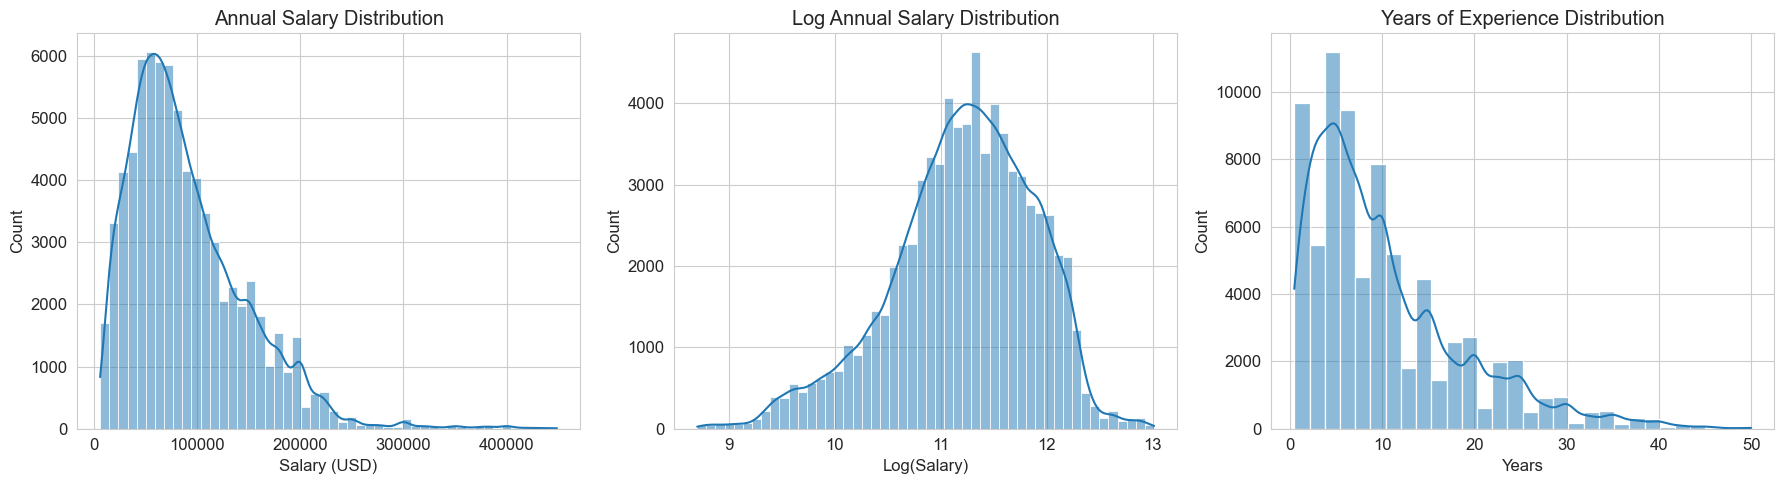

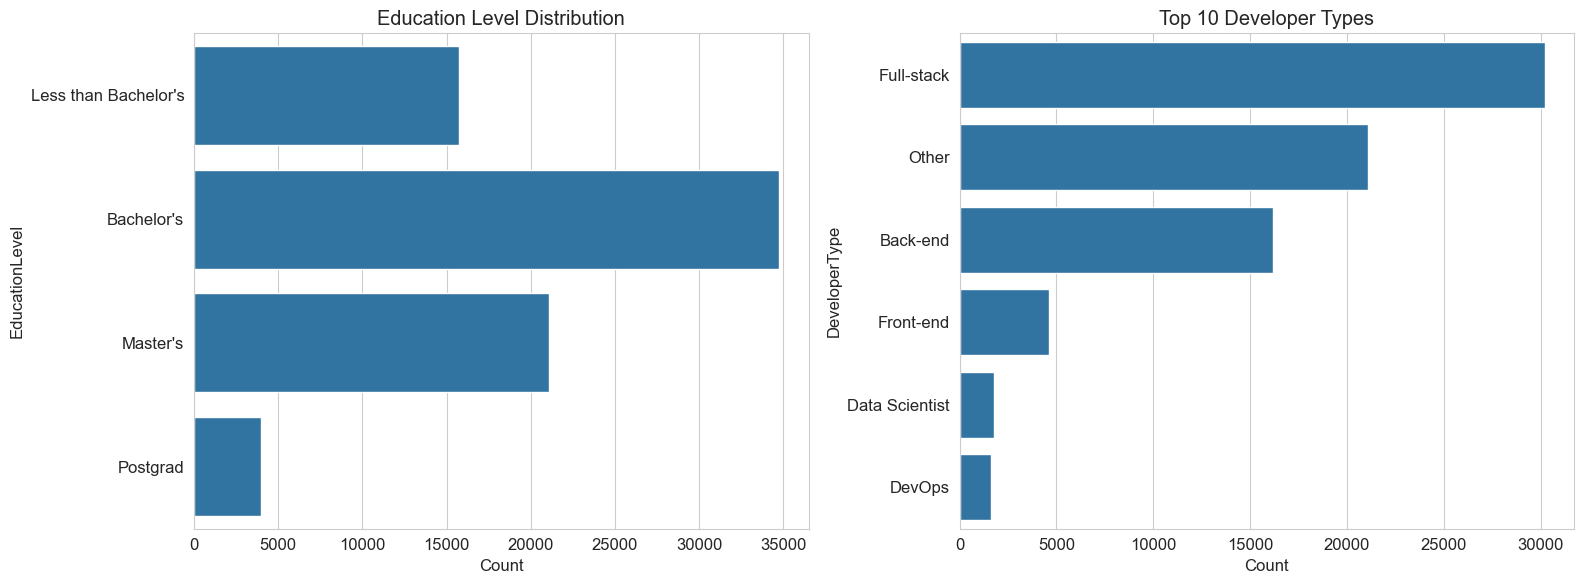

C:\Users\PC\AppData\Local\Temp\ipykernel_13116\3427521428.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_stats, x='AvgSalary', y='Country', palette='viridis')


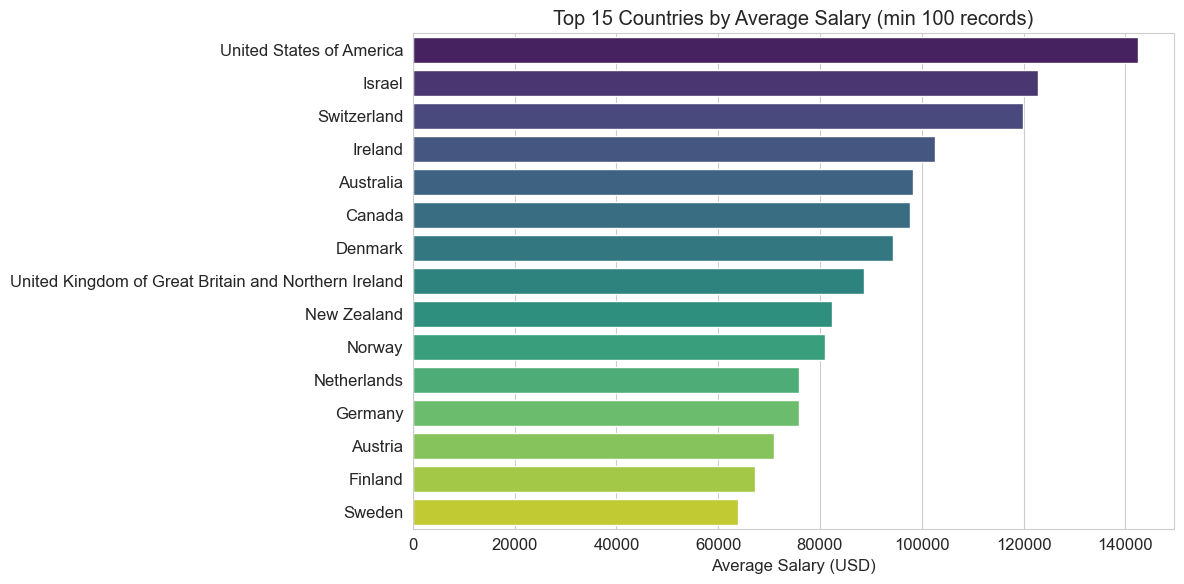

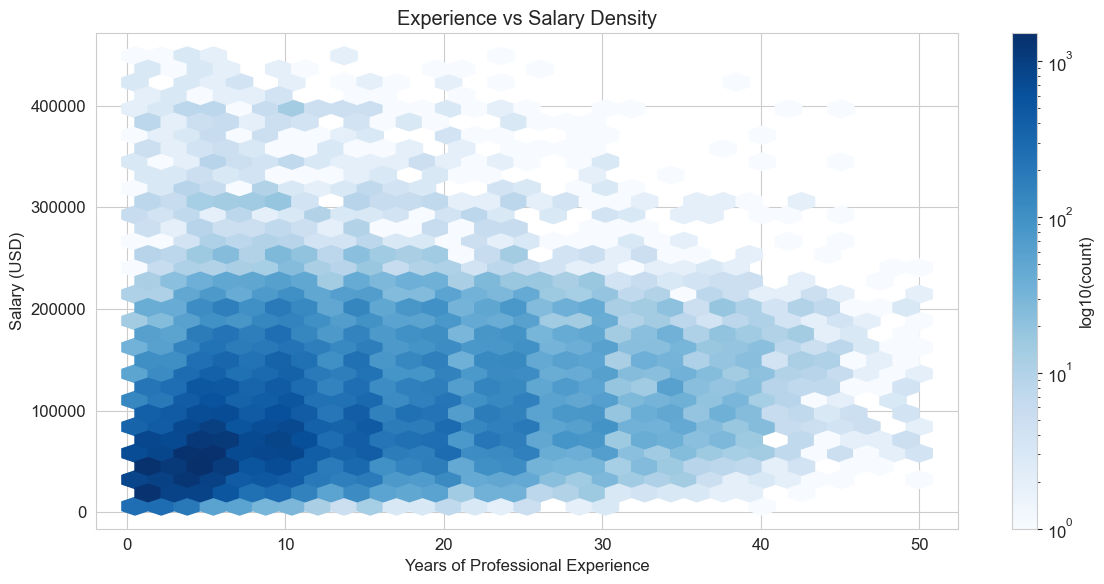

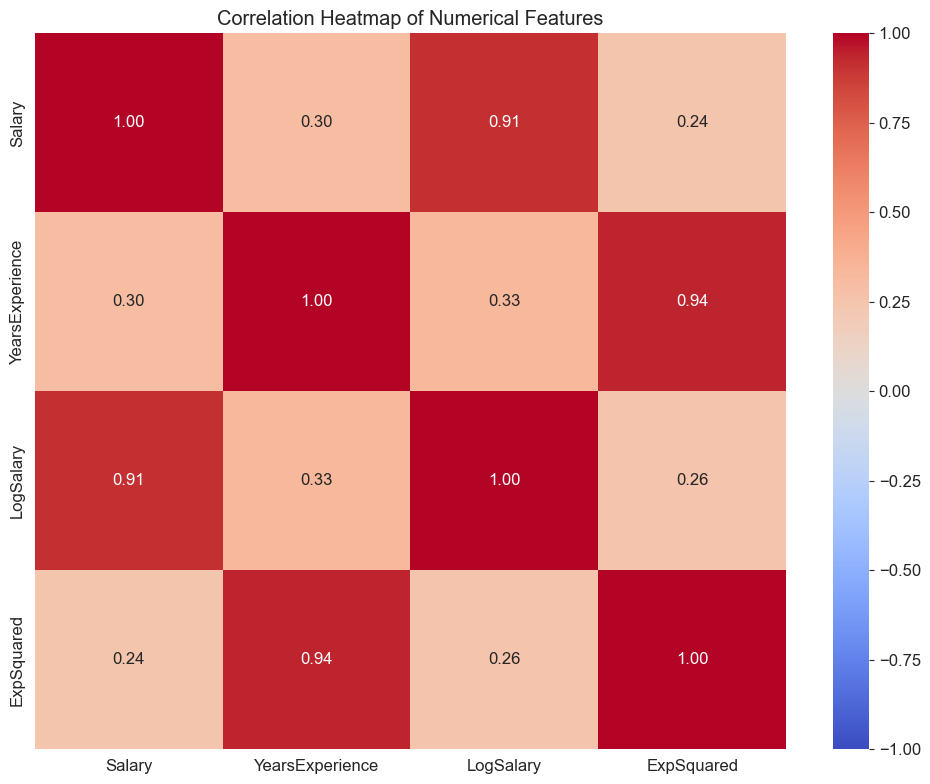

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

def plot_numerical_distributions(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Salary distribution
    sns.histplot(df['Salary'], bins=50, kde=True, ax=axes[0])
    axes[0].set_title('Annual Salary Distribution')
    axes[0].set_xlabel('Salary (USD)')

    # Log Salary distribution
    sns.histplot(df['LogSalary'], bins=50, kde=True, ax=axes[1])
    axes[1].set_title('Log Annual Salary Distribution')
    axes[1].set_xlabel('Log(Salary)')

    # Years of Experience
    sns.histplot(df['YearsExperience'], bins=30, kde=True, ax=axes[2])
    axes[2].set_title('Years of Experience Distribution')
    axes[2].set_xlabel('Years')

    plt.tight_layout()
    plt.show()

def plot_categorical_distributions(df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Education Level
    edu_order = ["Less than Bachelor's", "Bachelor's", "Master's", "Postgrad"]
    sns.countplot(data=df, y='EducationLevel', order=edu_order, ax=axes[0])
    axes[0].set_title('Education Level Distribution')
    axes[0].set_xlabel('Count')

    # Developer Type
    if 'DeveloperType' in df.columns:
        dev_counts = df['DeveloperType'].value_counts().nlargest(10)  # Show top 10 only
        sns.countplot(data=df, y='DeveloperType', order=dev_counts.index, ax=axes[1])
        axes[1].set_title('Top 10 Developer Types')
        axes[1].set_xlabel('Count')

    plt.tight_layout()
    plt.show()

def plot_top_countries(df, min_records=100):
    country_stats = df.groupby('Country').agg(
        AvgSalary=('Salary', 'mean'),
        MedianSalary=('Salary', 'median'),
        Count=('Salary', 'count')
    ).reset_index()

    country_stats = country_stats[country_stats['Count'] >= min_records]
    country_stats = country_stats.sort_values('AvgSalary', ascending=False).head(15)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=country_stats, x='AvgSalary', y='Country', palette='viridis')
    plt.title(f'Top 15 Countries by Average Salary (min {min_records} records)')
    plt.xlabel('Average Salary (USD)')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

def plot_experience_analysis(df):
    fig, ax = plt.subplots(figsize=(12, 6))

    df_clean = df.dropna(subset=['YearsExperience', 'Salary'])

    hb = ax.hexbin(df_clean['YearsExperience'], df_clean['Salary'],
                 gridsize=30, cmap='Blues', bins='log')
    ax.set_title('Experience vs Salary Density')
    ax.set_xlabel('Years of Professional Experience')
    ax.set_ylabel('Salary (USD)')

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label('log10(count)')

    plt.tight_layout()
    plt.show()

def plot_correlation_analysis(df):
    numerical_cols = ['Salary', 'YearsExperience', 'LogSalary', 'ExpSquared']
    df_numeric = df[numerical_cols].select_dtypes(include=[np.number])

    plt.figure(figsize=(10, 8))
    sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm',
                center=0, fmt='.2f', vmin=-1, vmax=1)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.tight_layout()
    plt.show()

def perform_comprehensive_eda(df):
    print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns")
    print("\nMissing values per column:")
    print(df.isnull().sum())

    plot_numerical_distributions(df)
    plot_categorical_distributions(df)

    plot_top_countries(df)
    plot_experience_analysis(df)
    plot_correlation_analysis(df)

perform_comprehensive_eda(data)

# 6. Feature Preparation

In [ ]:

features = ['Country', 'EducationLevel', 'YearsExperience', 'ExpSquared']
optional_features = ['DeveloperType', 'CompanySize', 'RemoteWork']
for feat in optional_features:
    if feat in data.columns:
        features.append(feat)

categorical_features = [f for f in features if f not in ['YearsExperience', 'ExpSquared']]
numeric_features = [f for f in features if f in ['YearsExperience', 'ExpSquared']]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', 'passthrough', numeric_features)
])


# 7. Train-Test Split

In [ ]:

X = data[features]
y = data['LogSalary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 8. Feature Transformation

In [ ]:

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


# 9. Model Training

In [ ]:

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42
    }
    model = XGBRegressor(**params)
    return -np.mean(cross_val_score(model, X_train_processed, y_train, cv=5, scoring='neg_mean_squared_error'))

study = optuna.create_study(direction='minimize')
study.optimize(xgb_objective, n_trials=30)

best_xgb = XGBRegressor(**study.best_params, random_state=42)
best_xgb.fit(X_train_processed, y_train)

rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train_processed, y_train)

stack = StackingRegressor(
    estimators=[('xgb', best_xgb), ('rf', rf)],
    final_estimator=RidgeCV()
)
stack.fit(X_train_processed, y_train)


[I 2025-05-11 01:18:47,099] A new study created in memory with name: no-name-70e6afb9-9a05-4f06-baba-a75034a511c2
[I 2025-05-11 01:18:52,708] Trial 0 finished with value: 0.169678816919331 and parameters: {'n_estimators': 345, 'max_depth': 4, 'learning_rate': 0.041237410124977336, 'subsample': 0.8901929296867397, 'colsample_bytree': 0.7749205676612312}. Best is trial 0 with value: 0.169678816919331.
[I 2025-05-11 01:19:05,644] Trial 1 finished with value: 0.17892992156557877 and parameters: {'n_estimators': 336, 'max_depth': 8, 'learning_rate': 0.1282607376215936, 'subsample': 0.7294673528365639, 'colsample_bytree': 0.6575211226859718}. Best is trial 0 with value: 0.169678816919331.
[I 2025-05-11 01:19:10,238] Trial 2 finished with value: 0.1992964064343079 and parameters: {'n_estimators': 254, 'max_depth': 3, 'learning_rate': 0.021170468692362318, 'subsample': 0.6890205563447005, 'colsample_bytree': 0.8960205111446722}. Best is trial 0 with value: 0.169678816919331.
[I 2025-05-11 01:1

StackingRegressor(estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.7800109905138831,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            inter...
                                            learning_rate=0.15150344015449715,
                                            max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=450, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                              ('rf',
                               RandomForestRegressor(max_depth=15,
                                                     n_estimators=200,
                                                     random_state=42))],
                  final_estimator=RidgeCV())

# 10. Model Evaluation


XGBoost Performance:
RMSE (log scale): 0.4090
R² Score: 0.6381
RMSE (USD): $38,936.35


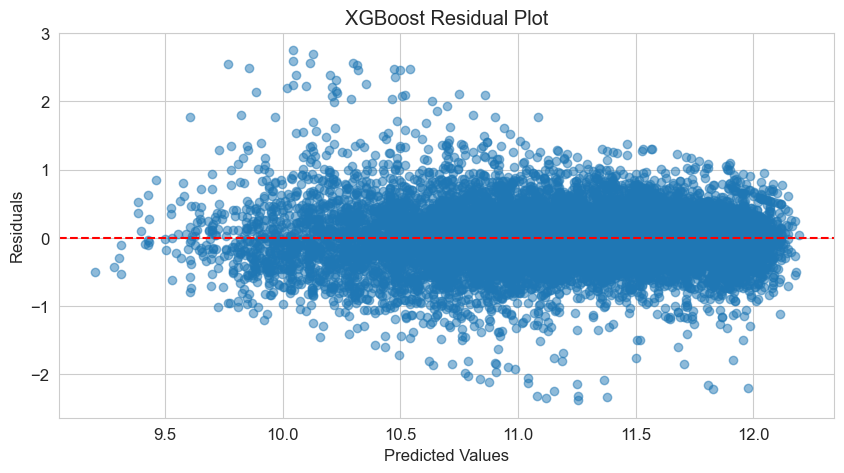


Random Forest Performance:
RMSE (log scale): 0.4350
R² Score: 0.5907
RMSE (USD): $40,146.40


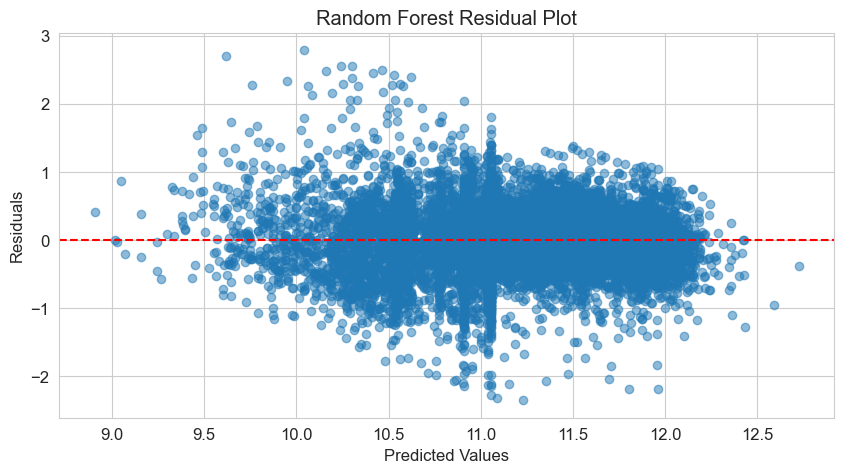


Stacked Model Performance:
RMSE (log scale): 0.4088
R² Score: 0.6385
RMSE (USD): $38,925.23


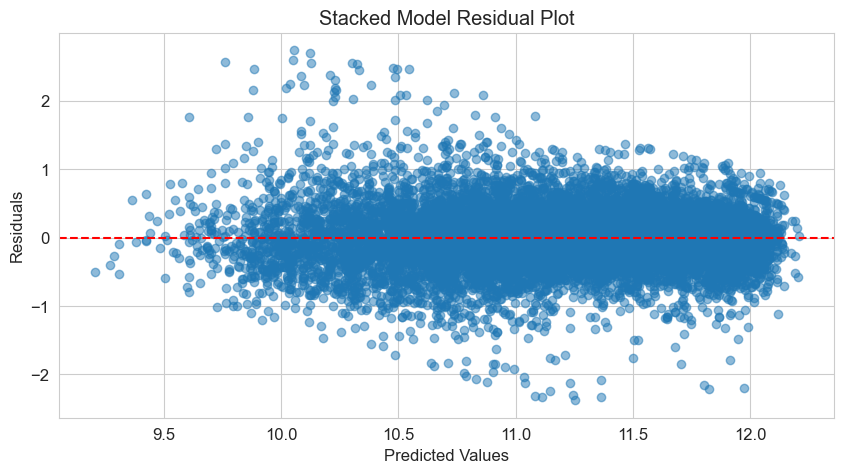

In [ ]:

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name} Performance:")
    print(f"RMSE (log scale): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred)
    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    print(f"RMSE (USD): ${rmse_orig:,.2f}")

    # Plot residuals
    plt.figure(figsize=(10, 5))
    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'{name} Residual Plot')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.show()

    return rmse, r2

results = {}
for name, model in [('XGBoost', best_xgb), ('Random Forest', rf), ('Stacked Model', stack)]:
        rmse, r2 = evaluate_model(name, model, X_test_processed, y_test)
        results[name] = {'RMSE': rmse, 'R2': r2}

# 11. Save Models

In [ ]:

joblib.dump(stack, "salary_predictor.joblib")
joblib.dump(preprocessor, "preprocessor.joblib")


['preprocessor.joblib']

# 12. Testing

In [ ]:
def predict_salary(input_data, model=None, preprocessor=None):
    try:

        if model is None:
            model = joblib.load('salary_predictor.joblib')
        if preprocessor is None:
            preprocessor = joblib.load('preprocessor.joblib')


        years_exp = float(input_data.get('YearsExperience', 5))
        input_df = pd.DataFrame([{
            'Country': input_data.get('Country', 'United States'),
            'EducationLevel': input_data.get('EducationLevel', "Bachelor's"),
            'YearsExperience': years_exp,
            'ExpSquared': years_exp**2,
            'DeveloperType': input_data.get('DeveloperType', 'Full-stack'),
            'CompanySize': input_data.get('CompanySize', 'Medium (10-99)'),
            'RemoteWork': input_data.get('RemoteWork', 'Hybrid')
        }])

        processed_input = preprocessor.transform(input_df)
        log_pred = model.predict(processed_input)[0]
        return np.expm1(log_pred)
    except Exception as e:
        print(f"\nPrediction Error: {str(e)}")
        print("Required features: Country, EducationLevel, YearsExperience, [DeveloperType, CompanySize, RemoteWork]")
        return None

example_input = {
    'Country': 'United States',
    'EducationLevel': "Master's",
    'YearsExperience': 5,
    'DeveloperType': 'Data Scientist',
    'CompanySize': 'Large (100-999)',
    'RemoteWork': 'Remote'
}

predicted_salary = predict_salary(example_input)
if predicted_salary is not None:
    print(f"\nSuccessful Prediction:")
    print(f"Input Features: {example_input}")
    print(f"Predicted Salary: ${predicted_salary:,.2f}")


Successful Prediction:
Input Features: {'Country': 'United States', 'EducationLevel': "Master's", 'YearsExperience': 5, 'DeveloperType': 'Data Scientist', 'CompanySize': 'Large (100-999)', 'RemoteWork': 'Remote'}
Predicted Salary: $63,341.10
